In [17]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.datasets import fetch_california_housing

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import r2_score

In [18]:
RANDOM_STATE = 42

In [20]:
data = fetch_california_housing(as_frame=True)

x = data.data
y = data.target

In [22]:
rf = RandomForestRegressor()
cross_val_score(rf, x, y, cv=3, scoring='r2').mean()

np.float64(0.6532002037062891)

In [ ]:
gb = GradientBoostingRegressor()

cross_val_score(gb, x, y, cv=3, scoring='r2').mean()

np.float64(0.6801216836981715)

Подбор гиперпараметров бустинга

* разбиваем данные на train и test
* на train по кросс-валидации при помощи GridSearchCV ищем наилучшие гиперпараметры модели
* оцениваем качество модели с наилучшими гиперпараметрами на test

In [23]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=RANDOM_STATE)

Гиперпараметры бустинга (gradient boosting)

* n_estimators=100 - число деревьев в лесе 
* learning_rate=0.1 - градиентный шаг (= степень доверия каждой модели в композиции)
* гиперпараметры деревьев:
  * criterion='squared_error'
  * max_depth=None
  * min_samples_split=2
  * random_state=None

In [ ]:
params = {'n_estimators': np.arange(10, 200, 20),
          'max_depth': np.arange(2, 20, 3)}

gs = GridSearchCV(GradientBoostingRegressor(), params, cv=3, scoring='r2', verbose=2)

gs.fit(xtrain, ytrain)

In [ ]:
gs.best_score_, gs.best_estimator_
# 0.8244124183295582
# GradientBoostingRegressor(max_depth=8, n_estimators=190)

In [ ]:
params = {'max_features': [None, 'sqrt', 'log2']}

gs = GridSearchCV(GradientBoostingRegressor(n_estimators = 170, max_depth = 8), params, cv=3, scoring='r2', verbose=2)

gs.fit(xtrain, ytrain)

In [ ]:
gs.best_score_, gs.best_estimator_
# 0.8296675722761929
# GradientBoostingRegressor(max_depth=8, max_features='log2', n_estimators=170)

In [25]:
model = GradientBoostingRegressor(n_estimators = 170, learning_rate = 0.1, max_depth = 8, max_features='log2')

model.fit(xtrain, ytrain)

pred = model.predict(xtest) 

r2_score(ytest, pred)

0.8438684351920887

learning_rate влияет на качество бустинга

Стратегия такая: после подбора гиперпараметров мы уменьшаем learning_rate до 0.01-0.03  
(то есть если значение по умолчанию 0.1, то уменьшаем в 10 раз), и во столько же раз увеличиваем число деревьев.

In [26]:
model = GradientBoostingRegressor(n_estimators = 1700, learning_rate = 0.01, max_depth = 8, max_features='log2')

model.fit(xtrain, ytrain)

pred = model.predict(xtest) 

r2_score(ytest, pred)

0.851337879394569

При помощи случайного леса в предыдущем уроке нам удалось добиться качества r2=0.851.

Бустинг значительно превзошел по качеству алгоритм случайного леса

Text(0, 0.5, 'r2')

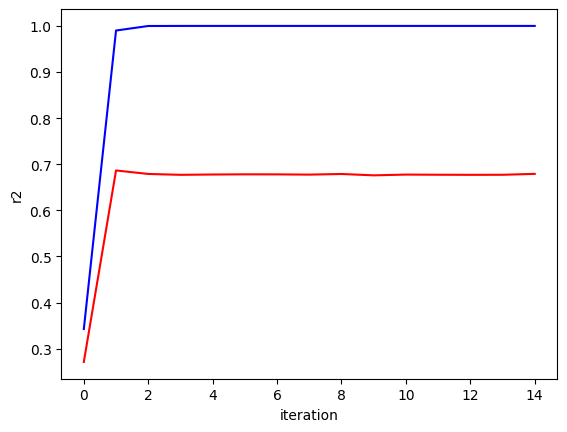

In [27]:
r2_train = []
r2_test = []

for n in range(2, 300, 20):
    model = GradientBoostingRegressor(n_estimators = n, max_depth = 20)
    model.fit(xtrain, ytrain)

    pred_train = model.predict(xtrain)
    pred_test = model.predict(xtest)

    r2_train.append(r2_score(ytrain, pred_train))
    r2_test.append(r2_score(ytest, pred_test))

plt.plot(r2_train, color='blue')
plt.plot(r2_test, color='red')
plt.xlabel('iteration')
plt.ylabel('r2')

На графике видно, что качество на трейне всегда растет, при этом качество на тесте со временем уменьшается. Это важное отличие бустинга от леса - он склонен к переобучению.

Поэтому необходимо подобрать такое число деревьев, при котором качество на тестовых данных максимальное, и больше деревьев не брать.